In [48]:
!pip install pandas seaborn scikit-learn --quiet


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [50]:
csv_path = "Internetusage_Beginnertask03.csv"
df = pd.read_csv(csv_path)
df.head()


,name,start_time,usage_time,IP,MAC,upload,download,total_transfer,seession_break_reason
0,user1,2022-05-10 02:59:32,00:00:36:28,10.55.14.222,48:E7:DA:58:22:E9,15861.76,333168.64,349030.40,Idle-Timeout
1,user1,2022-05-10 18:53:27,00:01:49:56,10.55.2.253,48:E7:DA:58:22:E9,16957.44,212152.32,229109.76,Idle-Timeout
2,user1,2022-05-10 21:20:44,00:01:35:00,10.55.2.253,48:E7:DA:58:22:E9,14080.0,195153.92,209233.92,Idle-Timeout
3,user1,2022-05-11 00:37:42,00:00:26:00,10.55.2.253,48:E7:DA:58:22:E9,5242.88,40806.4,46049.28,Idle-Timeout
4,user1,2022-05-11 02:59:38,00:00:11:52,10.55.2.253,48:E7:DA:58:22:E9,22067.2,10772.48,32839.68,Idle-Timeout


In [51]:
df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")

for col in ["upload", "download", "total_transfer"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["start_time", "upload", "download", "total_transfer"]).reset_index(drop=True)
df.head()


,name,start_time,usage_time,IP,MAC,upload,download,total_transfer,seession_break_reason
0,user1,2022-05-10 02:59:32,00:00:36:28,10.55.14.222,48:E7:DA:58:22:E9,15861.76,333168.64,349030.40,Idle-Timeout
1,user1,2022-05-10 18:53:27,00:01:49:56,10.55.2.253,48:E7:DA:58:22:E9,16957.44,212152.32,229109.76,Idle-Timeout
2,user1,2022-05-10 21:20:44,00:01:35:00,10.55.2.253,48:E7:DA:58:22:E9,14080.00,195153.92,209233.92,Idle-Timeout
3,user1,2022-05-11 00:37:42,00:00:26:00,10.55.2.253,48:E7:DA:58:22:E9,5242.88,40806.40,46049.28,Idle-Timeout
4,user1,2022-05-11 02:59:38,00:00:11:52,10.55.2.253,48:E7:DA:58:22:E9,22067.20,10772.48,32839.68,Idle-Timeout


In [52]:
df["hour"] = df["start_time"].dt.hour
df["dayofweek"] = df["start_time"].dt.dayofweek
df["day"] = df["start_time"].dt.day
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)


In [53]:
def duration_to_seconds(s):
    if pd.isna(s):
        return np.nan
    parts = str(s).split(":")
    try:
        parts = [int(p) for p in parts]
        if len(parts) == 4:
            h, m, sec, extra = parts
        elif len(parts) == 3:
            h, m, sec = parts
        else:
            return np.nan
        return h * 3600 + m * 60 + sec
    except Exception:
        return np.nan

df["usage_seconds"] = df["usage_time"].apply(duration_to_seconds)
df = df.dropna(subset=["usage_seconds"]).reset_index(drop=True)
df.head()


,name,start_time,usage_time,IP,MAC,upload,download,total_transfer,seession_break_reason,hour,dayofweek,day,hour_sin,hour_cos,usage_seconds
0,user1,2022-05-10 02:59:32,00:00:36:28,10.55.14.222,48:E7:DA:58:22:E9,15861.76,333168.64,349030.40,Idle-Timeout,2,1,10,0.500000,8.660254e-01,36
1,user1,2022-05-10 18:53:27,00:01:49:56,10.55.2.253,48:E7:DA:58:22:E9,16957.44,212152.32,229109.76,Idle-Timeout,18,1,10,-1.000000,-1.836970e-16,109
2,user1,2022-05-10 21:20:44,00:01:35:00,10.55.2.253,48:E7:DA:58:22:E9,14080.00,195153.92,209233.92,Idle-Timeout,21,1,10,-0.707107,7.071068e-01,95
3,user1,2022-05-11 00:37:42,00:00:26:00,10.55.2.253,48:E7:DA:58:22:E9,5242.88,40806.40,46049.28,Idle-Timeout,0,2,11,0.000000,1.000000e+00,26
4,user1,2022-05-11 02:59:38,00:00:11:52,10.55.2.253,48:E7:DA:58:22:E9,22067.20,10772.48,32839.68,Idle-Timeout,2,2,11,0.500000,8.660254e-01,11


In [54]:
df["intensity_bps"] = df["total_transfer"] / df["usage_seconds"]
df[["total_transfer", "usage_seconds", "intensity_bps"]].head()


,total_transfer,usage_seconds,intensity_bps
0,349030.40,36,9695.288889
1,229109.76,109,2101.924404
2,209233.92,95,2202.462316
3,46049.28,26,1771.126154
4,32839.68,11,2985.425455


In [62]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["intensity_bps"]).reset_index(drop=True)


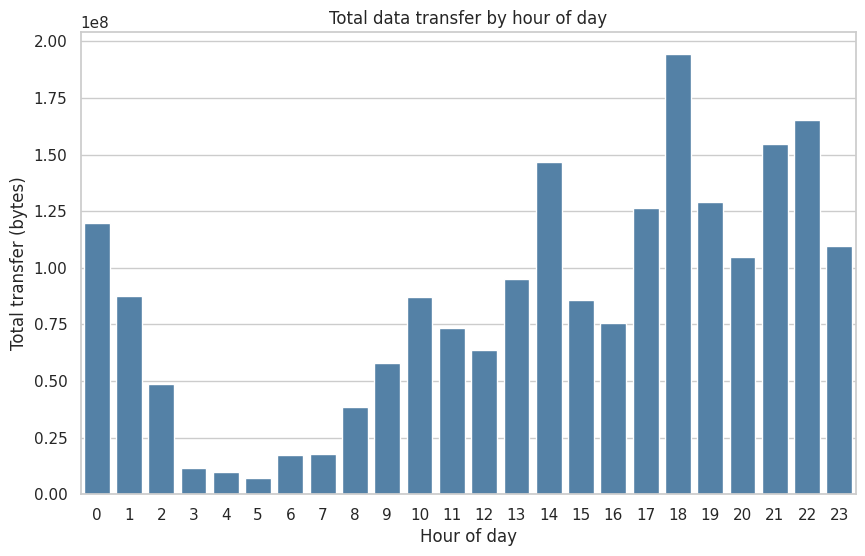

In [63]:
hourly_usage = df.groupby("hour")["total_transfer"].sum().reset_index()

sns.barplot(data=hourly_usage, x="hour", y="total_transfer", color="steelblue")
plt.title("Total data transfer by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Total transfer (bytes)")
plt.show()


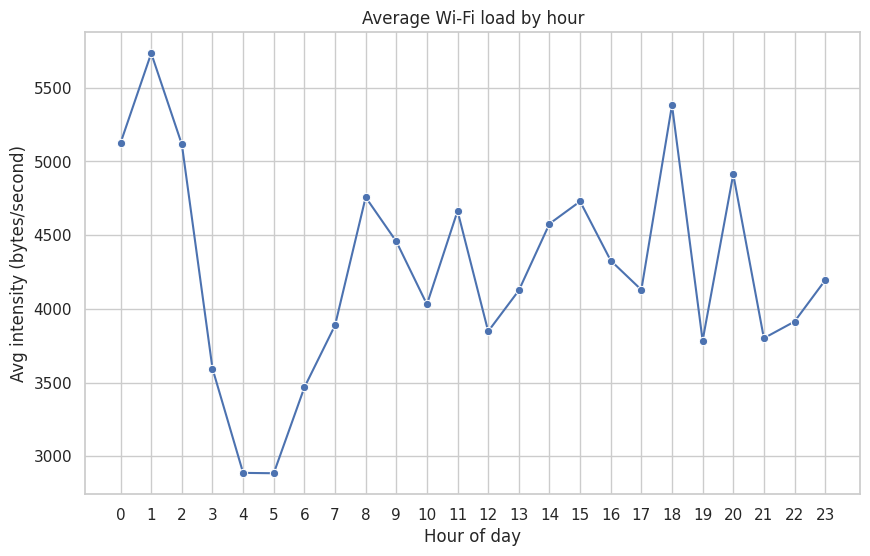

In [64]:
hourly_intensity = df.groupby("hour")["intensity_bps"].mean().reset_index()

sns.lineplot(data=hourly_intensity, x="hour", y="intensity_bps", marker="o")
plt.title("Average Wi-Fi load by hour")
plt.xlabel("Hour of day")
plt.ylabel("Avg intensity (bytes/second)")
plt.xticks(range(0, 24))
plt.show()


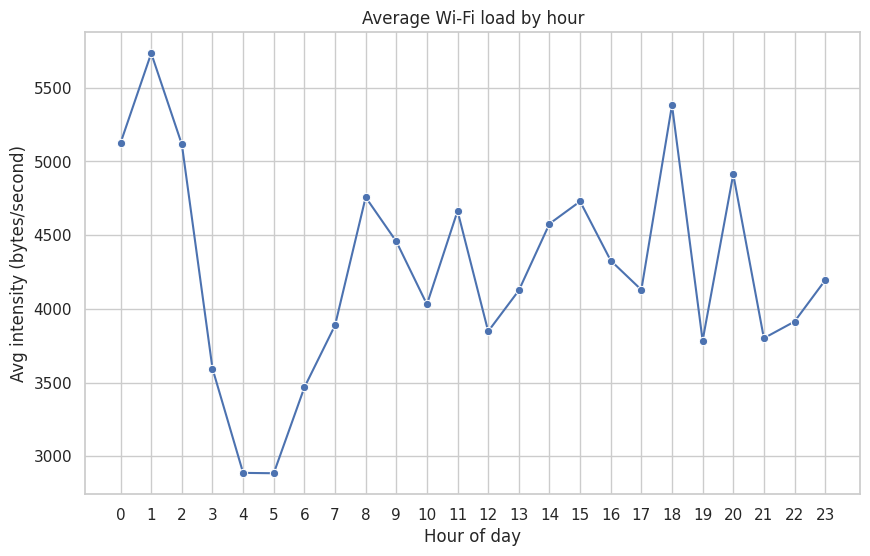

In [65]:
hourly_intensity = df.groupby("hour")["intensity_bps"].mean().reset_index()

sns.lineplot(data=hourly_intensity, x="hour", y="intensity_bps", marker="o")
plt.title("Average Wi-Fi load by hour")
plt.xlabel("Hour of day")
plt.ylabel("Avg intensity (bytes/second)")
plt.xticks(range(0, 24))
plt.show()


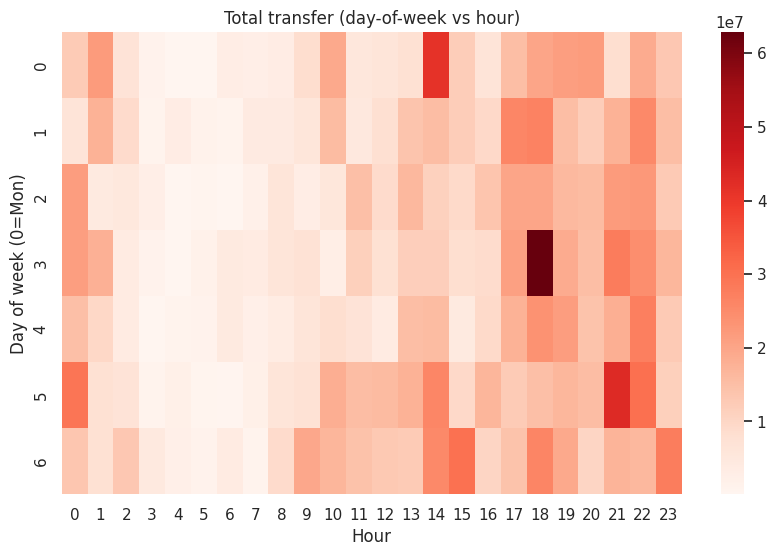

In [66]:
pivot_usage = df.pivot_table(
    index="dayofweek",
    columns="hour",
    values="total_transfer",
    aggfunc="sum"
)

sns.heatmap(pivot_usage, cmap="Reds")
plt.title("Total transfer (day-of-week vs hour)")
plt.xlabel("Hour")
plt.ylabel("Day of week (0=Mon)")
plt.show()


In [67]:
feature_cols = ["hour", "dayofweek", "usage_seconds", "hour_sin", "hour_cos"]

X = df[feature_cols]
y = df["intensity_bps"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [68]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)


In [69]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.3f}")


MAE  : 3811.50
RMSE : 8516.57
R^2  : -0.020


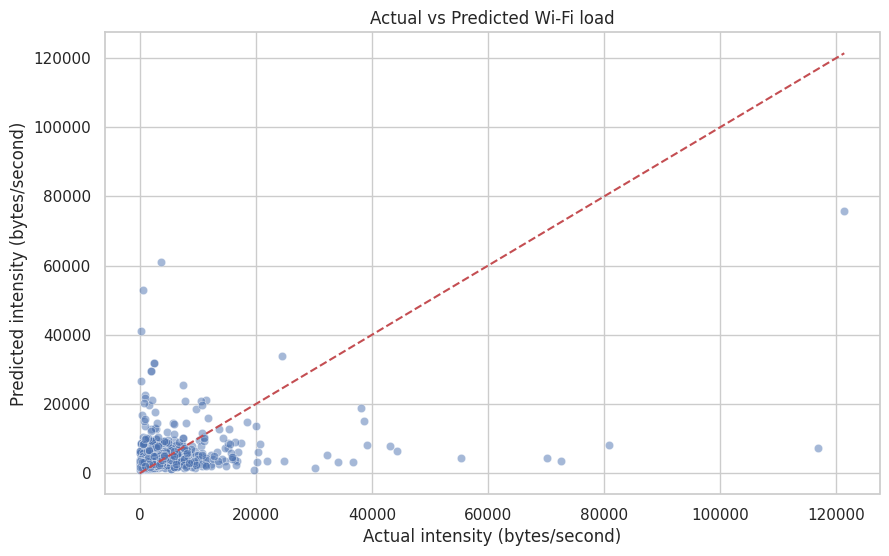

In [70]:
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual intensity (bytes/second)")
plt.ylabel("Predicted intensity (bytes/second)")
plt.title("Actual vs Predicted Wi-Fi load")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.show()


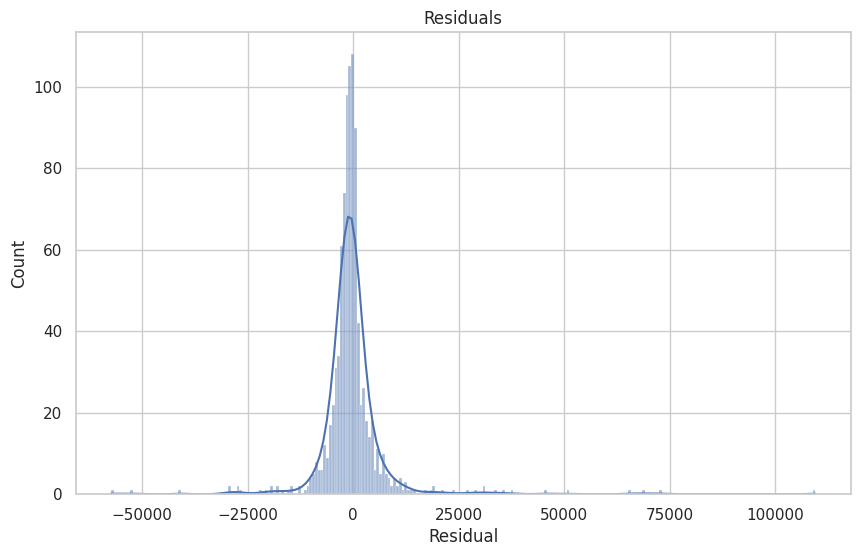

In [71]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title("Residuals")
plt.xlabel("Residual")
plt.show()


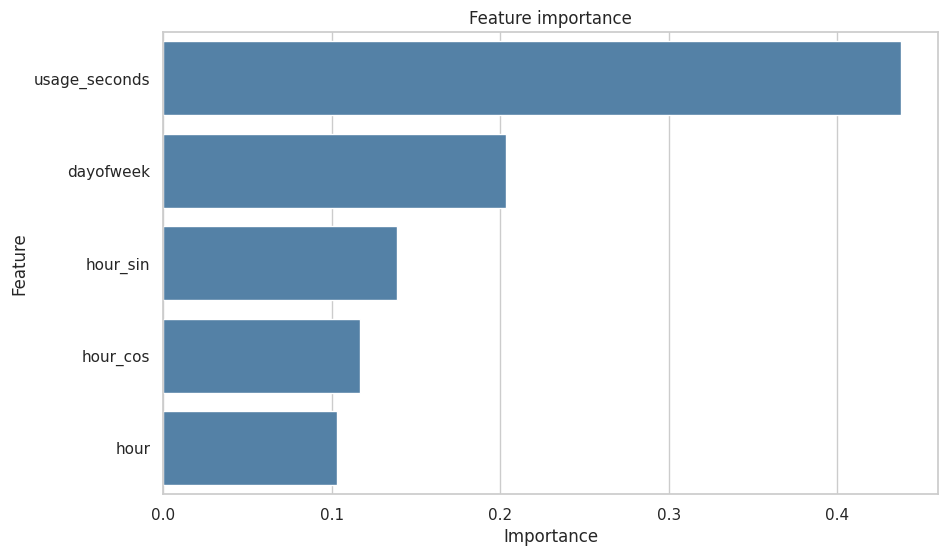

,0
usage_seconds,0.438155
dayofweek,0.203306
hour_sin,0.138937
hour_cos,0.116519
hour,0.103083


In [72]:
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

sns.barplot(x=feature_importance, y=feature_importance.index, color="steelblue")
plt.title("Feature importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

feature_importance


In [73]:
X_all_scaled = scaler.transform(df[feature_cols])
df["pred_intensity_bps"] = rf.predict(X_all_scaled)

hourly_pred = df.groupby("hour")["pred_intensity_bps"].mean().reset_index()
hourly_sorted = hourly_pred.sort_values("pred_intensity_bps", ascending=False)

peak_hours = hourly_sorted.head(3)
best_hours = hourly_sorted.tail(3).sort_values("pred_intensity_bps")

print("Peak hours (heaviest predicted Wi-Fi load):")
print(peak_hours)

print("\nBest hours for binge-watching / downloads:")
print(best_hours)


Peak hours (heaviest predicted Wi-Fi load):
   hour  pred_intensity_bps
1     1         6146.186379
8     8         5473.044014
0     0         5367.200956

Best hours for binge-watching / downloads:
   hour  pred_intensity_bps
4     4         2570.465742
5     5         2803.947917
6     6         3160.015063


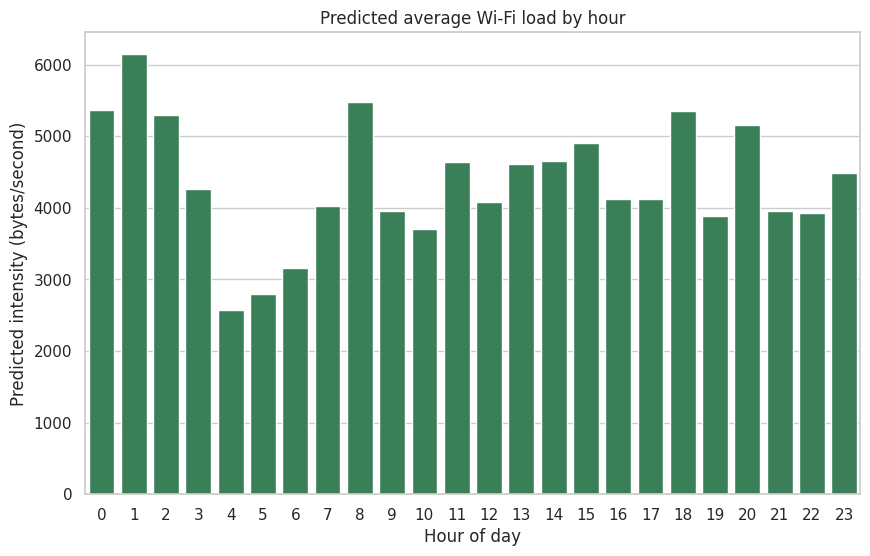

In [74]:
sns.barplot(data=hourly_pred, x="hour", y="pred_intensity_bps", color="seagreen")
plt.title("Predicted average Wi-Fi load by hour")
plt.xlabel("Hour of day")
plt.ylabel("Predicted intensity (bytes/second)")
plt.show()
